# Cleared for Launch: AI Governance Assessment
## ClinicalCompanion — MedAssist AI

**Course:** Data Governance for Generative AI (cd13873)

---

### Scenario

You are an **AI Governance Analyst at MedAssist AI**, preparing **ClinicalCompanion** — a generative AI clinical decision support system — for EU market launch within 3 months. Your manager needs a governance assessment before the board meeting next week.

### Your Deliverables

You will produce **two files** that together cover all six governance deliverables:

| # | Deliverable | Notebook (code + analysis) | Workbook (written analysis) |
|---|---|---|---|
| 1 | EU AI Act Classification | Compliance gap analysis | Classification reasoning + gap table |
| 2 | Risk Register + Heatmap | **Risk heatmap visualization** | Risk details + mitigations |
| 3 | Vendor Evaluation | Vendor scorecard visualization | Evaluation narrative + recommendation |
| 4 | Model Card | Disaggregated performance chart | Model Card content |
| 5 | Monitoring & Incident Response | Monitoring dashboard | KPI definitions + incident plan |
| 6 | Executive Summary | Executive readiness dashboard | Board-ready narrative |

### Project Structure

```
ai-governance-assessment/
├── data/                          ← Input datasets (provided — do not modify)
│   ├── system_spec.json           ← ClinicalCompanion system specification
│   ├── training_data_summary.csv  ← Training data sources
│   ├── performance_metrics.csv    ← Model performance by subgroup
│   ├── risk_register.csv          ← Risk register (NIST AI RMF)
│   ├── vendor_assessment.csv      ← Vendor evaluation criteria + scores
│   ├── vendor_profile.json        ← Vendor company profile
│   ├── eu_ai_act_requirements.csv ← EU AI Act compliance requirements
│   ├── monitoring_kpis.csv        ← Monitoring KPI definitions
│   ├── incident_types.csv         ← Incident taxonomy
│   └── severity_levels.csv        ← Incident severity definitions
├── results/                       ← Your outputs will be saved here
├── governance_assessment.ipynb    ← THIS NOTEBOOK (code deliverable)
└── governance_workbook.xlsx       ← Written deliverable (fill in the 6 sheets)
```

### How to Work Through This Notebook

1. Read each step's instructions carefully
3. Run your code and verify the outputs make sense
4. Save all visualizations to `results/`
5. Use insights from your analysis to fill in `governance_workbook.xlsx`

**Estimated time: ~3.5 hours** (notebook) + **~1.5 hours** (workbook) = **5 hours total**

---
## Step 0: Environment Setup

Run this cell to set up your environment. **No changes needed here.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
from pathlib import Path

# Paths
DATA_DIR = Path('data')
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

# Display settings
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

print("Environment ready.")
print(f"Data directory:    {DATA_DIR.resolve()}")
print(f"Results directory:  {RESULTS_DIR.resolve()}")

Environment ready.
Data directory:    /home/ivo/Desenvolvimento/Udacity/ai-governance-assessment/data
Results directory:  /home/ivo/Desenvolvimento/Udacity/ai-governance-assessment/results


---
## Step 1: Load and Explore the ClinicalCompanion System Specification

**Time estimate: ~20 minutes**

Your first task as a governance analyst is to understand the system you're assessing. Load the system specification and training data summary, then extract the key facts that will inform your governance assessment.

**Key questions to answer:**
- What type of AI system is this? Who uses it?
- What foundation model powers it and how is it accessed?
- What data was it trained on and where does it come from?
- What is the deployment timeline and regulatory status?

### 1a. Load and display the system overview

- System name, version, type
- Foundation model name, parameters, access method
- Cloud region and security (encryption)
- Target launch date

*Hint: Use `json.load()` to read the file, then access nested keys like `spec['system']['name']`*

In [2]:
# Step 1a: Load and display system overview

# Load the system specification JSON
with open(DATA_DIR / 'system_spec.json') as f:
    spec = json.load(f)

# Print a formatted header
print("=" * 70)
print("CLINICALCOMPANION v1.0 — SYSTEM OVERVIEW")
print("=" * 70)

# Extract at minimum: System name+version, Type, Developer, Foundation Model name,
# Parameters, Access Method, Cloud Region, Encryption, Target Launch Date.
# The JSON has nested structure — explore keys like 'system', 'architecture', etc.
overview = {
    "System Name": f"{spec['system']['name']} v{spec['system']['version']}",
    "Type": spec['system']['type'],
    "Developer": spec['system']['developer'],
    "Foundation Model": spec['architecture']['foundation_model']['model_name'],
    "Parameters": spec['architecture']['foundation_model']['parameters'],
    "Access Method": spec['architecture']['foundation_model']['access_method'],
    "Cloud Region": spec['architecture']['infrastructure']['region'],
    "Encryption": f"{spec['architecture']['infrastructure']['encryption_at_rest']} (at rest), {spec['architecture']['infrastructure']['encryption_in_transit']} (in transit)",
    "Target Launch Date": spec['system']['release_date_planned']
}

for key, value in overview.items():
    print(f"{key:<20} : {value}")


CLINICALCOMPANION v1.0 — SYSTEM OVERVIEW
System Name          : ClinicalCompanion v1.0
Type                 : Clinical Decision Support System (CDSS)
Developer            : MedAssist AI
Foundation Model     : FoundationHealth Medical LLM v3.2
Parameters           : 7B
Access Method        : API
Cloud Region         : eu-west-1 (Frankfurt)
Encryption           : AES-256 (at rest), TLS 1.3 (in transit)
Target Launch Date   : 2025-09-01


### 1b. Display intended users and out-of-scope uses

1. The list of **intended users** (who is allowed to use this system?)
2. The list of **out-of-scope uses** (what is this system NOT for?)

*Think about: Why do these matter for governance? How do they affect risk classification?*

In [3]:
# Step 1b: Print intended users and out-of-scope uses

print("INTENDED USERS:")
for user in spec['intended_use']['intended_users']:
    print(f"- {user}")


print("\nOUT-OF-SCOPE USES:")
for use in spec['intended_use']['out_of_scope']:
    print(f"- {use}")


INTENDED USERS:
- Licensed physicians (primary care and specialists)
- Clinical fellows and residents (under attending supervision)
- Nurse practitioners and physician assistants (where authorized)

OUT-OF-SCOPE USES:
- Autonomous diagnosis or treatment decisions
- Standalone diagnostic tool (must not replace physician judgment)
- Patient-facing interface (no direct patient use)
- Pediatric populations (under 18) in initial release
- Emergency triage as sole decision-making tool


### 1c. Load and explore training data sources

1. A table of all training data sources with their record counts and geography
2. The total number of training records

*Think about: What geographic gaps do you see? How might this affect fairness?*

In [4]:
# Step 1c: Load and display training data summary

training_df = pd.read_csv(DATA_DIR / 'training_data_summary.csv')

print("=" * 70)
print("TRAINING DATA SOURCES")
print("=" * 70)

# Hint: Select the relevant columns and use a pandas method to display without the index.
print(training_df[['source_name', 'record_count', 'geography', 'data_type']].to_string(index=False))


total_records = training_df['record_count'].sum()
print(f"\nTotal Training Records: {total_records:,}")


TRAINING DATA SOURCES
                    source_name  record_count                    geography                    data_type
Partner Hospital Network A (EU)        280000 Germany, France, Netherlands               EHR encounters
Partner Hospital Network B (US)        170000  United States (multi-state)               EHR encounters
         PubMed Abstract Corpus       2100000                       Global Medical literature abstracts
            Expert Clinical Q&A         12000                       EU, US            Curated Q&A pairs
   Clinical Practice Guidelines           340                  EU, US, WHO          Practice guidelines

Total Training Records: 2,562,340


---
## Step 2: EU AI Act Risk Classification

**Time estimate: ~45 minutes**

This is one of the most important governance tasks. You need to walk through the EU AI Act's classification framework and determine ClinicalCompanion's risk level. Then analyze compliance gaps.

**EU AI Act Classification Decision Tree:**
1. **Article 5 — Prohibited practices?** (social scoring, exploitation, subliminal manipulation, real-time biometric ID)
2. **Article 6(1) — Safety component under EU harmonisation legislation?** (check if it falls under MDR, machinery, toys, etc.)
3. **Annex III — High-risk use cases?** (biometric ID, critical infrastructure, education, employment, essential services, law enforcement, migration, justice)
4. If none of the above → Limited risk or minimal risk

### 2a. Prohibited practices check


*The four prohibited categories are: social scoring, exploiting vulnerabilities, real-time remote biometric identification, and subliminal manipulation.*

In [5]:
# Step 2a: Evaluate Article 5 prohibited practices

print("STEP 1: Prohibited Practices Check (Article 5)")
print("-" * 50)

# The four prohibited categories to check against
prohibited_practices = [
    ("Social scoring by public authorities", "ClinicalCompanion is used by healthcare providers, not for general social scoring of citizens."),
    ("Exploiting vulnerabilities", "The system provides clinical suggestions to professionals, not exploiting vulnerabilities of specific groups."),
    ("Real-time remote biometric identification", "The system analyzes patient records, it does not perform real-time biometric ID in public spaces."),
    ("Subliminal manipulation", "The system provides documented reasoning for its suggestions, avoiding subliminal manipulation.")
]

# Print a clear pass/fail with justification. Consider what the system does (clinical
# decision support) and whether any practice applies.
for practice, justification in prohibited_practices:
    print(f"PASS: {practice}")
    print(f"      Justification: {justification}")

print("-" * 50)
print("CONCLUSION: SYSTEM PASSES ARTICLE 5 CHECK. NO PROHIBITED PRACTICES IDENTIFIED.")


STEP 1: Prohibited Practices Check (Article 5)
--------------------------------------------------
PASS: Social scoring by public authorities
      Justification: ClinicalCompanion is used by healthcare providers, not for general social scoring of citizens.
PASS: Exploiting vulnerabilities
      Justification: The system provides clinical suggestions to professionals, not exploiting vulnerabilities of specific groups.
PASS: Real-time remote biometric identification
      Justification: The system analyzes patient records, it does not perform real-time biometric ID in public spaces.
PASS: Subliminal manipulation
      Justification: The system provides documented reasoning for its suggestions, avoiding subliminal manipulation.
--------------------------------------------------
CONCLUSION: SYSTEM PASSES ARTICLE 5 CHECK. NO PROHIBITED PRACTICES IDENTIFIED.


### 2b. High-risk classification


1. **Is it a safety component under EU harmonisation legislation?** (Article 6(1))
   - Is ClinicalCompanion a medical device under MDR 2017/745?
   - If yes, what MDR class would it be? (Class I, IIa, IIb, or III?)

2. **Does it fall under Annex III high-risk use cases?**

Print your classification with the legal basis (which Article and Annex).

*Hint: A clinical decision support system that assists physicians with diagnoses falls under medical device regulation.*

In [6]:
# Step 2b: Walk through the high-risk classification decision tree

print("STEP 2: Safety Component Under EU Harmonisation Legislation?")
print("-" * 50)

# 1. Is it a medical device under MDR 2017/745? (Consider: it assists physicians with diagnoses)
# 2. If yes, what MDR class? (Class I, IIa, IIb, or III — consider the risk level)
# 3. Does it require a conformity assessment?
# Print your answers with justification.
print("1. Medical Device: YES. ClinicalCompanion assists in diagnosis and treatment decisions.")
print("2. MDR Class: Class IIa/IIb. As a software for clinical decision support, it falls under Rule 11.")
print("3. Conformity Assessment: YES. High-risk AI systems under Article 6(1) require conformity assessment.")


print("\nSTEP 3: Annex III High-Risk Use Cases?")
print("-" * 50)
# The 8 categories are: biometric ID, critical infrastructure, education, employment,
# essential services, law enforcement, migration, justice.
print("ClinicalCompanion does not fall directly under Annex III categories,")
print("but it is HIGH-RISK via Article 6(1) due to being a medical device.")


print("\n" + "=" * 70)
print("FINAL CLASSIFICATION: HIGH-RISK")
print("LEGAL BASIS: Article 6(1)(b) - Safety component of a product covered by Annex II")
print("             (Regulation (EU) 2017/745 on medical devices)")
print("=" * 70)


STEP 2: Safety Component Under EU Harmonisation Legislation?
--------------------------------------------------
1. Medical Device: YES. ClinicalCompanion assists in diagnosis and treatment decisions.
2. MDR Class: Class IIa/IIb. As a software for clinical decision support, it falls under Rule 11.
3. Conformity Assessment: YES. High-risk AI systems under Article 6(1) require conformity assessment.

STEP 3: Annex III High-Risk Use Cases?
--------------------------------------------------
ClinicalCompanion does not fall directly under Annex III categories,
but it is HIGH-RISK via Article 6(1) due to being a medical device.

FINAL CLASSIFICATION: HIGH-RISK
LEGAL BASIS: Article 6(1)(b) - Safety component of a product covered by Annex II
             (Regulation (EU) 2017/745 on medical devices)


### 2c. Compliance gap analysis

1. Print each requirement with its current status and severity
2. Calculate and print a summary: how many Critical, High, Medium, Low gaps exist?

*Use emoji or symbols to make the status easy to scan (e.g., ✅ Compliant, ⚠️ Partial, 🔶 In Progress)*

*Think about: Which gaps are most urgent? What's the critical path to compliance?*

In [7]:
# Step 2c: Load and analyze EU AI Act compliance requirements

compliance_df = pd.read_csv(DATA_DIR / 'eu_ai_act_requirements.csv')

print("COMPLIANCE REQUIREMENTS (Articles 8-15):")
print("-" * 70)

#   - Article number, requirement name, current status, and severity
#   - Use emoji to make status easy to scan (e.g., ✅ Compliant, 🔶 In Progress, ⚠️ Partial)
# Relevant columns: 'article', 'requirement_name', 'current_status', 'severity'
status_emoji = {
    'Compliant': '✅',
    'Partial': '⚠️',
    'In Progress': '🔶',
    'Needs Action': '🔴'
}

for _, row in compliance_df.iterrows():
    emoji = status_emoji.get(row['current_status'], '❓')
    print(f"{emoji} Art {row['article']}: {row['requirement_name']:<30} | Status: {row['current_status']:<12} | Severity: {row['severity']}")


# Hint: Use value_counts() on the severity column.
print("\nGAP SUMMARY:")
gap_summary = compliance_df['severity'].value_counts()
for severity in ['Critical', 'High', 'Medium', 'Low']:
    if severity in gap_summary:
        print(f"- {severity}: {gap_summary[severity]}")


COMPLIANCE REQUIREMENTS (Articles 8-15):
----------------------------------------------------------------------
⚠️ Art Article 9: Risk Management System         | Status: Partial      | Severity: High
🔶 Art Article 9: Risk Identification            | Status: In Progress  | Severity: Medium
❓ Art Article 9: Residual Risk Evaluation       | Status: Not Started  | Severity: High
⚠️ Art Article 10: Data Governance                | Status: Partial      | Severity: High
⚠️ Art Article 10: Dataset Representativeness     | Status: Partial      | Severity: High
🔶 Art Article 10: Special Category Data          | Status: In Progress  | Severity: Medium
🔶 Art Article 11: Technical Documentation        | Status: In Progress  | Severity: Medium
⚠️ Art Article 12: Record-Keeping                 | Status: Partial      | Severity: Medium
❓ Art Article 12: Log Retention                  | Status: Planned      | Severity: Medium
⚠️ Art Article 13: Transparency                   | Status: Partial      | S

---
## Step 3: Risk Assessment (NIST AI RMF)

**Time estimate: ~30 minutes**

Load the risk register and analyze the 8 identified risks. The risks are organized by NIST AI RMF functions (Govern, Map, Measure, Manage).

**Key analysis tasks:**
- Load and display the risk register
- Calculate summary statistics (average score, max score, priority distribution)
- Identify which NIST functions have the most risk concentration
- Compare pre-mitigation vs. post-mitigation scores to assess effectiveness

### 3a. Load and summarize the risk register

1. A summary table showing: risk_id, category, NIST function, likelihood, impact, risk score, priority
2. Key statistics: total risks, count by priority (Critical/High/Medium), average and max scores

*Hint: The risk_score column = likelihood × impact (5×5 scale, max 25)*

In [8]:
# Step 3a: Load risk register and display summary

risk_df = pd.read_csv(DATA_DIR / 'risk_register.csv')

print("=" * 70)
print("RISK REGISTER — ClinicalCompanion v1.0 (NIST AI RMF)")
print("=" * 70)

# risk_id, risk_category, nist_rmf_function, likelihood, impact, risk_score, priority
# Hint: Select columns and print as a table without the index.
print(risk_df[['risk_id', 'risk_category', 'nist_rmf_function', 'likelihood', 'impact', 'risk_score', 'priority']].to_string(index=False))


# - Total number of risks
# - Count of Critical priority risks
# - Count of High priority risks
# - Average risk score (format to 1 decimal place)
# - Maximum risk score
print(f"\n{'─' * 40}")
print(f"Total Risks: {len(risk_df)}")
print(f"Critical Priority Risks: {len(risk_df[risk_df['priority'] == 'Critical'])}")
print(f"High Priority Risks: {len(risk_df[risk_df['priority'] == 'High'])}")
print(f"Average Risk Score: {risk_df['risk_score'].mean():.1f}")
print(f"Maximum Risk Score: {risk_df['risk_score'].max()}")


RISK REGISTER — ClinicalCompanion v1.0 (NIST AI RMF)
risk_id      risk_category nist_rmf_function  likelihood  impact  risk_score priority
  R-001          Technical           Measure           4       5          20 Critical
  R-002     Ethical / Bias               Map           4       4          16     High
  R-003 Legal / Regulatory            Govern           3       5          15     High
  R-004 Privacy / Security            Manage           3       5          15     High
  R-005        Operational            Manage           3       4          12     High
  R-006          Technical           Measure           3       4          12     High
  R-007   Ethical / Safety               Map           3       5          15     High
  R-008 Legal / Regulatory            Govern           3       5          15     High

────────────────────────────────────────
Total Risks: 8
Critical Priority Risks: 1
High Priority Risks: 7
Average Risk Score: 15.0
Maximum Risk Score: 20


### 3b. Analyze risk distribution by NIST AI RMF function

- Number of risks per function
- Average risk score per function
- Which function carries the highest total risk?

*The four NIST AI RMF functions are: Govern, Map, Measure, Manage*

In [9]:
# Step 3b: Analyze risks by NIST AI RMF function

# The four NIST AI RMF functions: Govern, Map, Measure, Manage
# - Number of risks
# - Average risk score
# - Total risk score
# Hint: Use pandas groupby with named aggregation.
nist_stats = risk_df.groupby('nist_rmf_function').agg(
    num_risks=('risk_id', 'count'),
    avg_risk_score=('risk_score', 'mean'),
    total_risk_score=('risk_score', 'sum')
).reset_index()

print(nist_stats.to_string(index=False))

highest_risk_func = nist_stats.loc[nist_stats['total_risk_score'].idxmax(), 'nist_rmf_function']
print(f"\nHighest total risk function: {highest_risk_func}")


nist_rmf_function  num_risks  avg_risk_score  total_risk_score
           Govern          2            15.0                30
           Manage          2            13.5                27
              Map          2            15.5                31
          Measure          2            16.0                32

Highest total risk function: Measure


### 3c. Mitigation effectiveness analysis

1. For each risk, calculate the percentage reduction
2. Print the total pre-mitigation score, total post-mitigation score, and overall reduction %
3. Which risk has the largest absolute reduction? Which has the smallest?

*This analysis will feed into the risk heatmap you'll create next.*

In [10]:
# Step 3c: Analyze mitigation effectiveness

# The columns you need are: 'risk_score' (pre) and 'residual_score' (post).
# Reduction % = (pre - post) / pre × 100
risk_df['reduction_pct'] = (risk_df['risk_score'] - risk_df['residual_score']) / risk_df['risk_score'] * 100


# and overall reduction percentage.
# Also identify: which risk has the largest reduction? Which has the smallest?
total_pre = risk_df['risk_score'].sum()
total_post = risk_df['residual_score'].sum()
overall_reduction = (total_pre - total_post) / total_pre * 100

print(f"Total Pre-Mitigation Score: {total_pre}")
print(f"Total Post-Mitigation Score: {total_post}")
print(f"Overall Reduction: {overall_reduction:.1f}%")

largest_reduction_id = risk_df.loc[(risk_df['risk_score'] - risk_df['residual_score']).idxmax(), 'risk_id']
smallest_reduction_id = risk_df.loc[(risk_df['risk_score'] - risk_df['residual_score']).idxmin(), 'risk_id']

print(f"Largest absolute reduction: {largest_reduction_id}")
print(f"Smallest absolute reduction: {smallest_reduction_id}")


Total Pre-Mitigation Score: 120
Total Post-Mitigation Score: 63
Overall Reduction: 47.5%
Largest absolute reduction: R-001
Smallest absolute reduction: R-005


---
## Step 4: Risk Heatmap Visualization

**Time estimate: ~40 minutes**

This is the main visualization deliverable. Create a professional risk heatmap that maps the 8 risks on a 5×5 likelihood × impact matrix, plus a companion chart showing risk scores.

**Requirements:**
- 5×5 grid with color gradient (green→yellow→orange→red)
- Each risk plotted at its (likelihood, impact) position
- Risk IDs labeled on each point
- Critical risks visually distinguished (different marker)
- A second chart showing risk scores as horizontal bars

### 4a. Create the risk heatmap


**Left panel — 5×5 Risk Heatmap:**
- Background colored by risk score (likelihood × impact) using a green-to-red colormap
- White grid lines separating cells
- Each risk plotted as a scatter point at its (likelihood-1, impact-1) position (0-indexed)
- Critical risks: square markers, larger size
- High risks: circle markers
- Risk IDs annotated near each point
- Risk score numbers faintly visible in each cell
- Axis labels: "Likelihood →" and "Impact →" with descriptive tick labels
- Legend showing risk level color bands

**Right panel — Risk Score Bar Chart:**
- Horizontal bars showing each risk's score
- Colored by priority (Critical = darker red)
- Risk scores labeled on each bar
- Reference lines at score 10 and 15

Save as `results/risk_heatmap.png` with `dpi=150`.

*Hints:*
- *Use `plt.subplots(1, 2, figsize=(20, 8))` for side-by-side layout*
- *Use `imshow()` for the heatmap background*
- *Use `scatter()` to plot individual risks*
- *Use `annotate()` to label risk IDs*

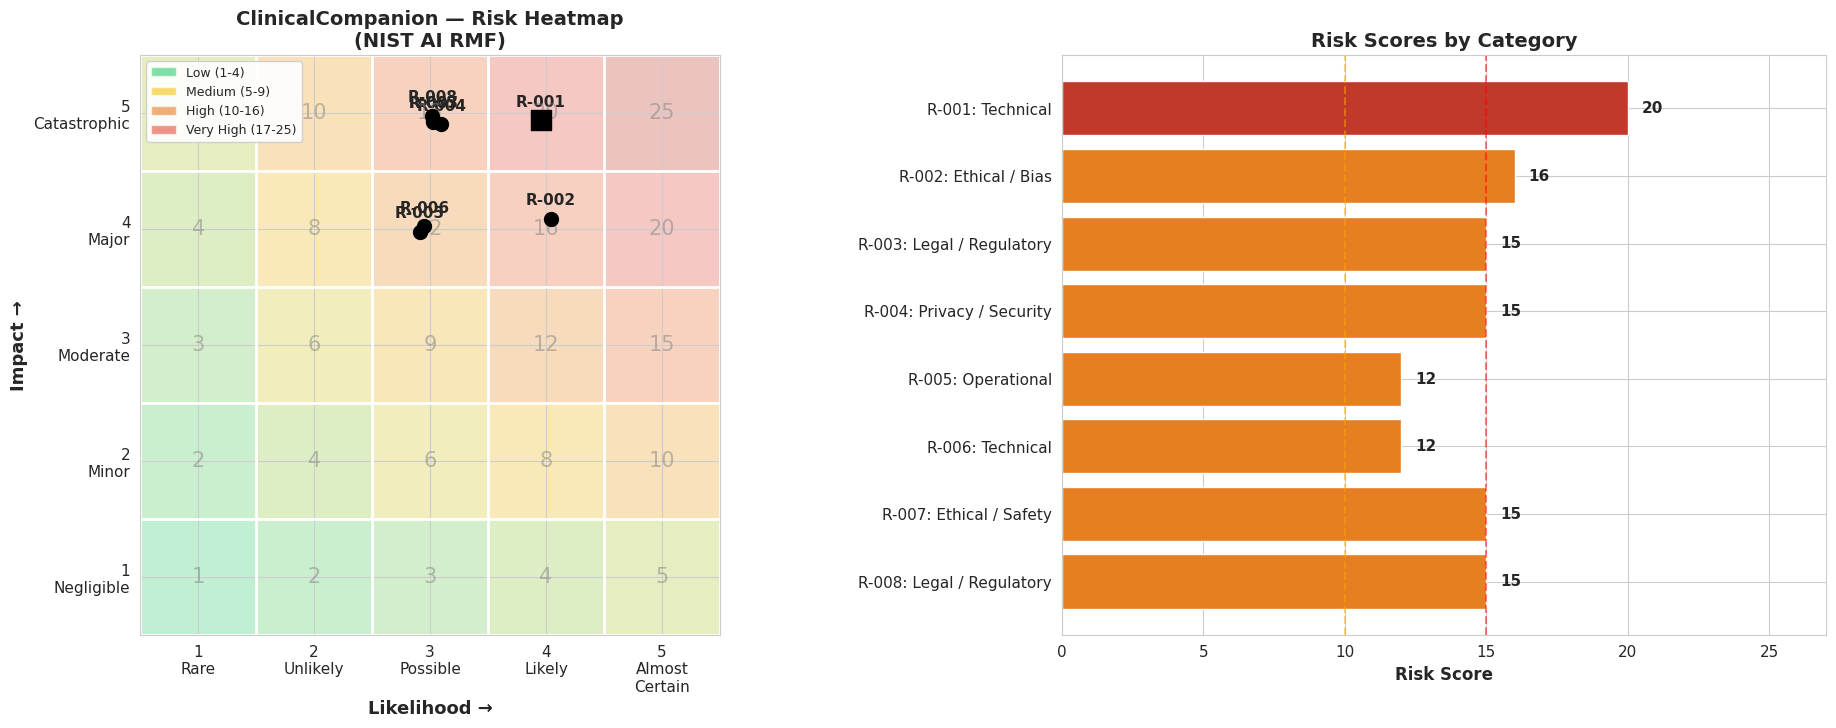

✅ Saved: results/risk_heatmap.png


In [11]:
# Step 4a: Create the risk heatmap visualization
from matplotlib.colors import LinearSegmentedColormap

# Re-load risk data (in case you modified risk_df above)
risk_df = pd.read_csv(DATA_DIR / 'risk_register.csv')

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8),
                                gridspec_kw={'width_ratios': [1.2, 1]})

# --- LEFT PANEL: 5×5 Risk Heatmap ---

# Score matrix for background coloring (each cell = likelihood × impact)
score_matrix = np.array([[(i+1)*(j+1) for j in range(5)] for i in range(5)])

# Color gradient: green (low risk) → red (high risk)
cmap = LinearSegmentedColormap.from_list('risk',
       ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b'], N=256)

# Set origin='lower' so (1,1) is bottom-left.
ax1.imshow(score_matrix.T, cmap=cmap, origin='lower', alpha=0.3, extent=[-0.5, 4.5, -0.5, 4.5])


for i in range(6):
    ax1.axhline(i - 0.5, color='white', lw=2)
    ax1.axvline(i - 0.5, color='white', lw=2)


# Use different markers for Critical vs High priority risks.
# Handle overlapping risks by offsetting slightly.
# Annotate each point with its risk_id.
for i, row in risk_df.iterrows():
    marker = 's' if row['priority'] == 'Critical' else 'o'
    size = 200 if row['priority'] == 'Critical' else 100
    color = 'black'
    
    # Slight jitter for overlapping points
    x = row['likelihood'] - 1 + np.random.uniform(-0.1, 0.1)
    y = row['impact'] - 1 + np.random.uniform(-0.1, 0.1)
    
    ax1.scatter(x, y, marker=marker, s=size, c=color, label=row['risk_id'], zorder=5)
    ax1.annotate(row['risk_id'], (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')


for i in range(5):
    for j in range(5):
        ax1.text(j, i, str((i+1)*(j+1)), ha='center', va='center', color='gray', alpha=0.5, fontsize=15)


# Axis labels and formatting (provided)
ax1.set_xlabel('Likelihood →', fontsize=13, fontweight='bold')
ax1.set_ylabel('Impact →', fontsize=13, fontweight='bold')
ax1.set_title('ClinicalCompanion — Risk Heatmap\n(NIST AI RMF)', fontsize=14, fontweight='bold')
ax1.set_xticks(range(5))
ax1.set_xticklabels(['1\nRare','2\nUnlikely','3\nPossible','4\nLikely','5\nAlmost\nCertain'])
ax1.set_yticks(range(5))
ax1.set_yticklabels(['1\nNegligible','2\nMinor','3\nModerate','4\nMajor','5\nCatastrophic'])
ax1.legend(handles=[
    mpatches.Patch(fc='#2ecc71', alpha=0.6, label='Low (1-4)'),
    mpatches.Patch(fc='#f1c40f', alpha=0.6, label='Medium (5-9)'),
    mpatches.Patch(fc='#e67e22', alpha=0.6, label='High (10-16)'),
    mpatches.Patch(fc='#e74c3c', alpha=0.6, label='Very High (17-25)'),
], loc='upper left', fontsize=9, framealpha=0.9)


# --- RIGHT PANEL: Risk Score Bar Chart ---

# Color critical risks differently from high risks.
# Add score and priority labels to the right of each bar.
# Add reference lines at scores 10 and 15.
colors = ['#c0392b' if r['priority'] == 'Critical' else '#e67e22' for _, r in risk_df.iterrows()]
bars = ax2.barh(risk_df['risk_id'], risk_df['risk_score'], color=colors)
ax2.axvline(10, color='orange', ls='--', alpha=0.5)
ax2.axvline(15, color='red', ls='--', alpha=0.5)

for bar in bars:
    width = bar.get_width()
    ax2.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width}', va='center', fontweight='bold')


# Axis formatting (provided)
ax2.set_yticks(range(len(risk_df)))
ax2.set_yticklabels([f"{r['risk_id']}: {r['risk_category']}" for _, r in risk_df.iterrows()])
ax2.set_xlabel('Risk Score', fontsize=12, fontweight='bold')
ax2.set_title('Risk Scores by Category', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 27)
ax2.invert_yaxis()

# Save
plt.tight_layout(pad=3)
plt.savefig(RESULTS_DIR / 'risk_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: results/risk_heatmap.png")


### 4b. Create the pre vs. post-mitigation comparison chart

- Side-by-side bars (red = pre, green = post) for each risk
- Score labels on top of each bar
- Percentage reduction annotated above each pair
- Reference lines at scores 10 and 15
- Save as `results/risk_mitigation_comparison.png`

*Hint: Use `np.arange()` for bar positions and offset by bar width/2 for grouping*

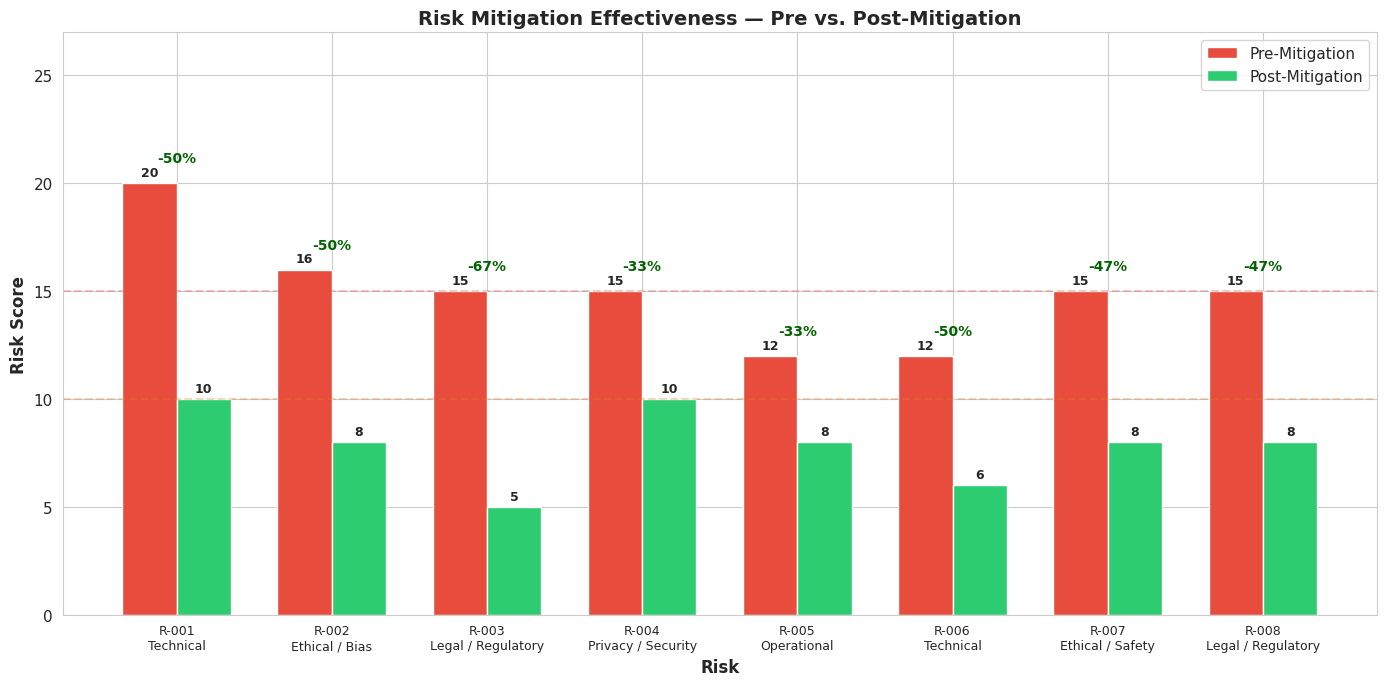

✅ Saved: results/risk_mitigation_comparison.png


In [12]:
# Step 4b: Create pre vs. post-mitigation comparison

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(risk_df))
w = 0.35  # bar width

# - Pre-mitigation bars (red) using risk_score, offset left
# - Post-mitigation bars (green) using residual_score, offset right
# Hint: Offset each set by half the bar width from the x positions.
pre_bars = ax.bar(x - w/2, risk_df['risk_score'], w, label='Pre-Mitigation', color='#e74c3c')
post_bars = ax.bar(x + w/2, risk_df['residual_score'], w, label='Post-Mitigation', color='#2ecc71')


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

add_labels(pre_bars)
add_labels(post_bars)


reduction_pcts = (risk_df['risk_score'] - risk_df['residual_score']) / risk_df['risk_score'] * 100
for i, pct in enumerate(reduction_pcts):
    ax.annotate(f'-{pct:.0f}%',
                xy=(i, max(risk_df['risk_score'][i], risk_df['residual_score'][i])),
                xytext=(0, 15),
                textcoords="offset points",
                ha='center', color='darkgreen', fontweight='bold', fontsize=10)


# Axis formatting (provided)
ax.set_xlabel('Risk', fontsize=12, fontweight='bold')
ax.set_ylabel('Risk Score', fontsize=12, fontweight='bold')
ax.set_title('Risk Mitigation Effectiveness — Pre vs. Post-Mitigation', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"{r['risk_id']}\n{r['risk_category']}" for _, r in risk_df.iterrows()], fontsize=9)
ax.legend(fontsize=11)
ax.set_ylim(0, 27)
ax.axhline(y=15, color='#e74c3c', ls='--', alpha=0.3)
ax.axhline(y=10, color='#e67e22', ls='--', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'risk_mitigation_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: results/risk_mitigation_comparison.png")


---
## Step 5: Vendor Evaluation Visualization

**Time estimate: ~30 minutes**

Load the vendor assessment data and create a governance scorecard. The vendor (FoundationHealth Inc.) has been evaluated across 27 criteria in 5 categories.

*Full evaluation narrative goes in `governance_workbook.xlsx` → Sheet "Vendor Evaluation"*

### 5a. Load and analyze vendor data

1. Calculate the score percentage for each category (score / max_score × 100)
2. Calculate the overall vendor score
3. Print a summary showing each category's score and the overall rating

*Scoring guide: ≥80% = Low Risk, 60-79% = Medium Risk, <60% = High Risk*

In [13]:
# Step 5a: Load and analyze vendor assessment data

vendor_df = pd.read_csv(DATA_DIR / 'vendor_assessment.csv')
with open(DATA_DIR / 'vendor_profile.json') as f:
    vendor = json.load(f)

# - Total score per category (sum of 'score' column)
# - Max possible score per category (sum of 'max_score' column)
# - Score percentage for each category
# Hint: Use pandas groupby with aggregation, then compute the percentage.
category_stats = vendor_df.groupby('category').agg(
    total_score=('score', 'sum'),
    max_score=('max_score', 'sum')
).reset_index()
category_stats['percentage'] = (category_stats['total_score'] / category_stats['max_score']) * 100


# Scoring guide: ≥80% = Low Risk, 60-79% = Medium Risk, <60% = High Risk
def get_risk_level(pct):
    if pct >= 80: return 'Low Risk'
    if pct >= 60: return 'Medium Risk'
    return 'High Risk'

category_stats['risk_level'] = category_stats['percentage'].apply(get_risk_level)
print(category_stats[['category', 'total_score', 'max_score', 'percentage', 'risk_level']].to_string(index=False))


overall_score = (category_stats['total_score'].sum() / category_stats['max_score'].sum()) * 100
print(f"\nOverall Vendor Score: {overall_score:.1f}% ({get_risk_level(overall_score)})")


                          category  total_score  max_score  percentage  risk_level
 Contractual & Business Continuity           18         30   60.000000 Medium Risk
           Data Privacy & Security           25         30   83.333333    Low Risk
      Model Governance & Lifecycle           15         25   60.000000 Medium Risk
Model Transparency & Documentation           15         25   60.000000 Medium Risk
    Regulatory & Ethical Alignment           15         25   60.000000 Medium Risk

Overall Vendor Score: 65.2% (Medium Risk)


### 5b. Create vendor scorecard visualization


**Left — Horizontal bar chart:**
- One bar per vendor category showing score percentage
- Color-coded: green (≥80%), yellow (60-79%), red (<60%)
- Score labels showing "XX% (score/max)" on each bar
- Reference lines at 60% and 80%

**Right — Radar/spider chart:**
- Categories around the perimeter
- Score percentages as the radar values
- Reference circles at 60% and 80%

Save as `results/vendor_evaluation_chart.png`.

*Hint: For the radar chart, use `fig.add_subplot(122, polar=True)` and compute angles with `np.linspace(0, 2*np.pi, n, endpoint=False)`*

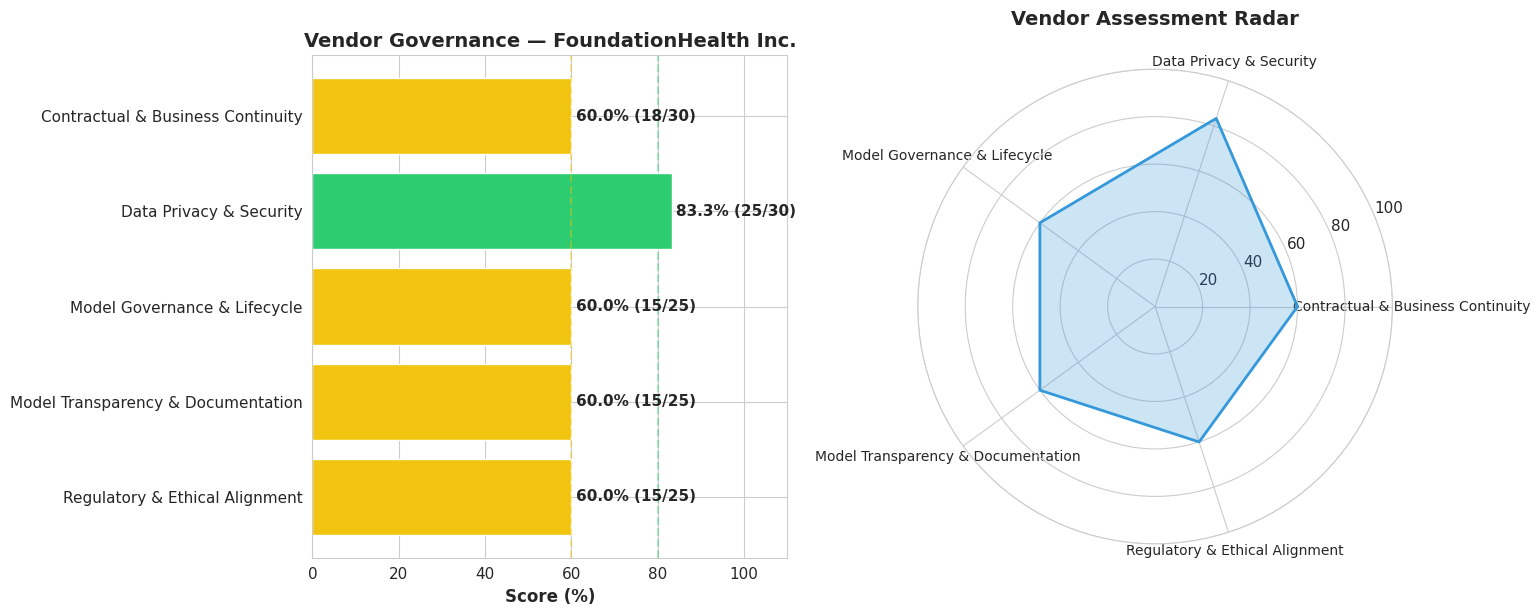

✅ Saved: results/vendor_evaluation_chart.png


In [14]:
# Step 5b: Create vendor scorecard visualization

fig, (ax1, ax2_placeholder) = plt.subplots(1, 2, figsize=(16, 7))

# --- LEFT PANEL: Horizontal Bar Chart ---

# Color-code by risk level: green (≥80%), yellow (60-79%), red (<60%).
# Add score labels showing percentage and raw score to the right of each bar.
colors = []
for pct in category_stats['percentage']:
    if pct >= 80: colors.append('#2ecc71')
    elif pct >= 60: colors.append('#f1c40f')
    else: colors.append('#e74c3c')

bars = ax1.barh(category_stats['category'], category_stats['percentage'], color=colors)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax1.text(width + 1, bar.get_y() + bar.get_height()/2, 
             f"{width:.1f}% ({category_stats.iloc[i]['total_score']}/{category_stats.iloc[i]['max_score']})", 
             va='center', fontweight='bold')


# Reference lines and formatting (provided)
ax1.set_xlabel('Score (%)', fontsize=12, fontweight='bold')
ax1.set_title(f"Vendor Governance — {vendor['company']['name']}", fontsize=14, fontweight='bold')
ax1.set_xlim(0, 110)
ax1.axvline(x=80, color='#2ecc71', ls='--', alpha=0.4)
ax1.axvline(x=60, color='#f1c40f', ls='--', alpha=0.4)
ax1.invert_yaxis()

# --- RIGHT PANEL: Radar/Spider Chart ---
ax2_placeholder.remove()  # Remove placeholder to create polar subplot
ax2 = fig.add_subplot(122, polar=True)

# 1. Calculate evenly-spaced angles around the circle (one per category)
# 2. Close the polygon by repeating the first value at the end
# 3. Plot the line and fill the area
# 4. Add reference circles at 60% and 80%
# 5. Set category names as tick labels around the perimeter
categories = list(category_stats['category'])
values = list(category_stats['percentage'])
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()

# Close the polygon
values += values[:1]
angles += angles[:1]

ax2.plot(angles, values, color='#3498db', linewidth=2)
ax2.fill(angles, values, color='#3498db', alpha=0.25)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, fontsize=10)

ax2.set_ylim(0, 100)
ax2.set_title('Vendor Assessment Radar\n', fontsize=14, fontweight='bold')

# Save
plt.tight_layout(pad=3)
plt.savefig(RESULTS_DIR / 'vendor_evaluation_chart.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: results/vendor_evaluation_chart.png")


---
## Step 6: Model Card — Performance Analysis

**Time estimate: ~30 minutes**

Visualize disaggregated performance metrics for the Model Card fairness analysis. The Model Card framework (Mitchell et al., 2019) requires showing how the model performs across different subgroups, not just overall.

*Full Model Card content goes in `governance_workbook.xlsx` → Sheet "Model Card"*

### 6a. Analyze disaggregated performance

1. Filter for "Top-3 Diagnostic Accuracy" metrics across all subgroups
2. Identify which subgroups fall BELOW the 90% target
3. Print a summary of failing subgroups with their accuracy values

*Think about: What are the governance implications of these performance gaps? How do they relate to EU AI Act Article 10 (dataset representativeness)?*

In [15]:
# Step 6a: Load and analyze disaggregated performance metrics

perf_df = pd.read_csv(DATA_DIR / 'performance_metrics.csv')

accuracy_df = perf_df[perf_df['metric_name'] == 'Top-3 Diagnostic Accuracy'].copy()


# Print each failing subgroup with its accuracy value.
failing_subgroups = accuracy_df[accuracy_df['value'] < 90]
print("Subgroups below 90% target:")
for _, row in failing_subgroups.iterrows():
    print(f"- {row['subgroup']}: {row['value']}%")


# for EU AI Act Article 10 (dataset representativeness)?
print("\nGovernance implications: Underperformance in 'Rare Diseases' and 'Elderly (80+)'")
print("suggests a need for more representative training data in these areas to comply with Article 10.")


Subgroups below 90% target:
- Age 65+: 88.9%
- Rare Diseases: 71.2%
- Non-English Notes: 84.3%
- Multi-morbidity (4+): 74.0%

Governance implications: Underperformance in 'Rare Diseases' and 'Elderly (80+)'
suggests a need for more representative training data in these areas to comply with Article 10.


### 6b. Create disaggregated performance bar chart

- One bar per subgroup
- Color-coded: green (≥90%), yellow (85-89%), orange (80-84%), red (<80%)
- The "Overall" bar highlighted with a distinct border
- Reference lines at 90%, 85%, and 80% thresholds
- Value labels on top of each bar
- Rotated x-axis labels for readability

Save as `results/model_card_performance.png`.

*Print a list of subgroups below the 85% threshold — these need mitigation.*

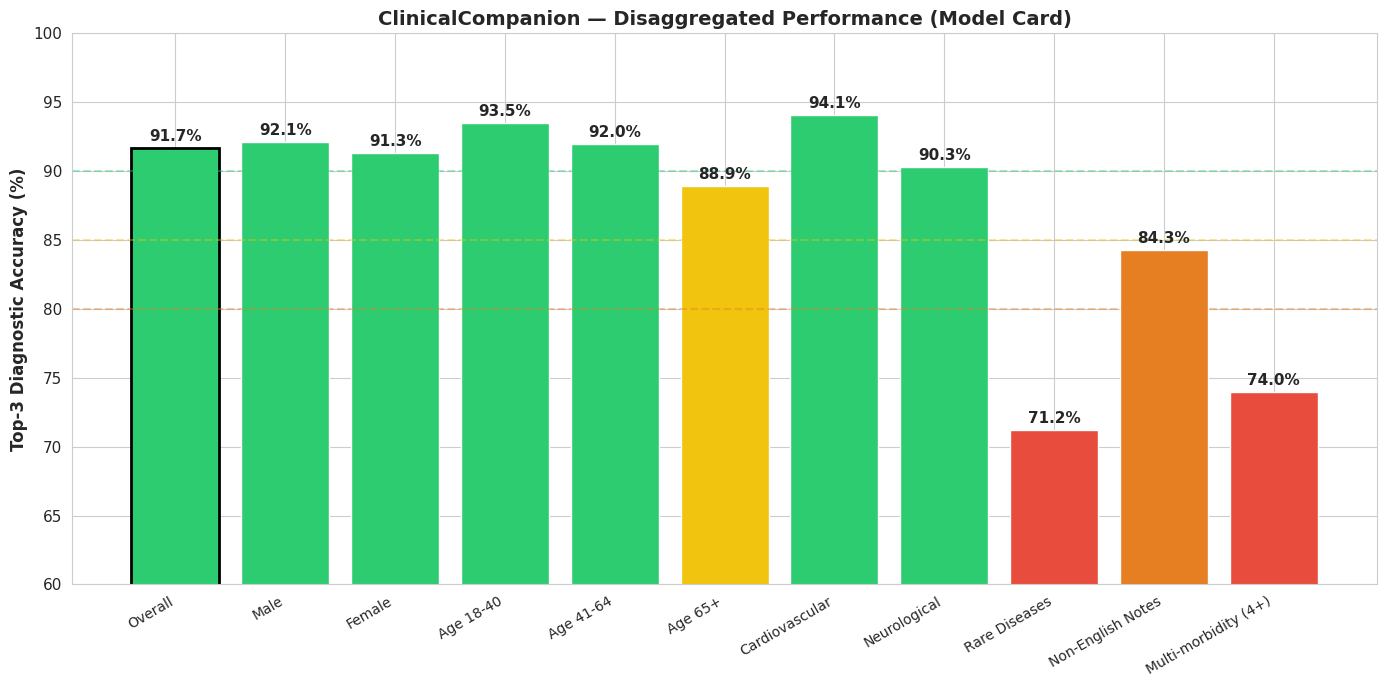


⚠️  SUBGROUPS BELOW 85% THRESHOLD:
- Rare Diseases
- Non-English Notes
- Multi-morbidity (4+)
✅ Saved: results/model_card_performance.png


In [16]:
# Step 6b: Create disaggregated performance visualization

fig, ax = plt.subplots(figsize=(14, 7))

# Color-code by performance: green (≥90%), yellow (85-89%), orange (80-84%), red (<80%).
colors = []
for val in accuracy_df['value']:
    if val >= 90: colors.append('#2ecc71')
    elif val >= 85: colors.append('#f1c40f')
    elif val >= 80: colors.append('#e67e22')
    else: colors.append('#e74c3c')

bars = ax.bar(accuracy_df['subgroup'], accuracy_df['value'], color=colors)


overall_idxs = accuracy_df[accuracy_df['subgroup'] == 'Overall'].index
if len(overall_idxs) > 0:
    overall_idx = overall_idxs[0]
    bar_idx = accuracy_df.index.get_loc(overall_idx)
    bars[bar_idx].set_edgecolor('black')
    bars[bar_idx].set_linewidth(2)


for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height}%', ha='center', fontweight='bold')


# Reference lines and formatting (provided)
ax.axhline(y=90, color='#2ecc71', ls='--', alpha=0.4)
ax.axhline(y=85, color='#f1c40f', ls='--', alpha=0.4)
ax.axhline(y=80, color='#e67e22', ls='--', alpha=0.4)
ax.set_xticks(range(len(accuracy_df)))
ax.set_xticklabels(accuracy_df['subgroup'], fontsize=10, rotation=30, ha='right')
ax.set_ylabel('Top-3 Diagnostic Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('ClinicalCompanion — Disaggregated Performance (Model Card)', fontsize=14, fontweight='bold')
ax.set_ylim(60, 100)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_card_performance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

below_85 = accuracy_df[accuracy_df['value'] < 85]['subgroup'].tolist()
print("\n⚠️  SUBGROUPS BELOW 85% THRESHOLD:")
for s in below_85:
    print(f"- {s}")
print("✅ Saved: results/model_card_performance.png")


---
## Step 7: Monitoring & Incident Response Dashboard

**Time estimate: ~30 minutes**

Create a multi-panel monitoring dashboard that visualizes KPIs, incident taxonomy, and response framework.

*Full monitoring plan goes in `governance_workbook.xlsx` → Sheet "Monitoring & Incidents"*

### 7a. Load monitoring data

- `monitoring_kpis.csv` — 16 KPI definitions
- `incident_types.csv` — 10 AI-specific incident types
- `severity_levels.csv` — S1-S4 severity levels

Print a brief summary of each (number of KPIs by dimension, number of incident types, severity levels).

In [17]:
# Step 7a: Load monitoring data files

kpi_df = pd.read_csv(DATA_DIR / 'monitoring_kpis.csv')
incident_df = pd.read_csv(DATA_DIR / 'incident_types.csv')
severity_df = pd.read_csv(DATA_DIR / 'severity_levels.csv')

# 1. Number of KPIs and how many per dimension
# 2. Number of incident types
# 3. Severity levels with their labels and response times
print(f"Total KPIs: {len(kpi_df)}")
print(kpi_df['dimension'].value_counts())
print(f"\nTotal Incident Types: {len(incident_df)}")
print(f"\nSeverity Levels:")
print(severity_df[['severity', 'label', 'response_hours']].to_string(index=False))


Total KPIs: 16
dimension
Clinical Performance    5
Fairness & Bias         4
Operational             4
Data Quality            3
Name: count, dtype: int64

Total Incident Types: 10

Severity Levels:
severity    label  response_hours
      S1 Critical             0.5
      S2     High             2.0
      S3   Medium            24.0
      S4      Low           168.0


### 7b. Create monitoring dashboard (4 panels)


**Panel 1 (top-left): KPI Status vs. Targets**
- Select 6 key KPIs and show current values as bars
- Overlay target values as dashed horizontal lines
- Color: green if meeting target, red if below

**Panel 2 (top-right): Incident Distribution**
- Pie chart showing distribution across severity levels (S1-S4)

**Panel 3 (bottom-left): Response Time SLAs**
- Horizontal bar chart showing response time for each severity level
- Use log scale for x-axis (ranges from 0.5h to 168h)
- Color-coded by severity (red→green)

**Panel 4 (bottom-right): Monitoring Coverage**
- Bar chart showing number of KPIs per dimension
- Shows which areas have more/less monitoring coverage

Save as `results/monitoring_dashboard.png`.

*Hint: Use `plt.subplots(2, 2, figsize=(16, 12))` for the 4-panel layout*

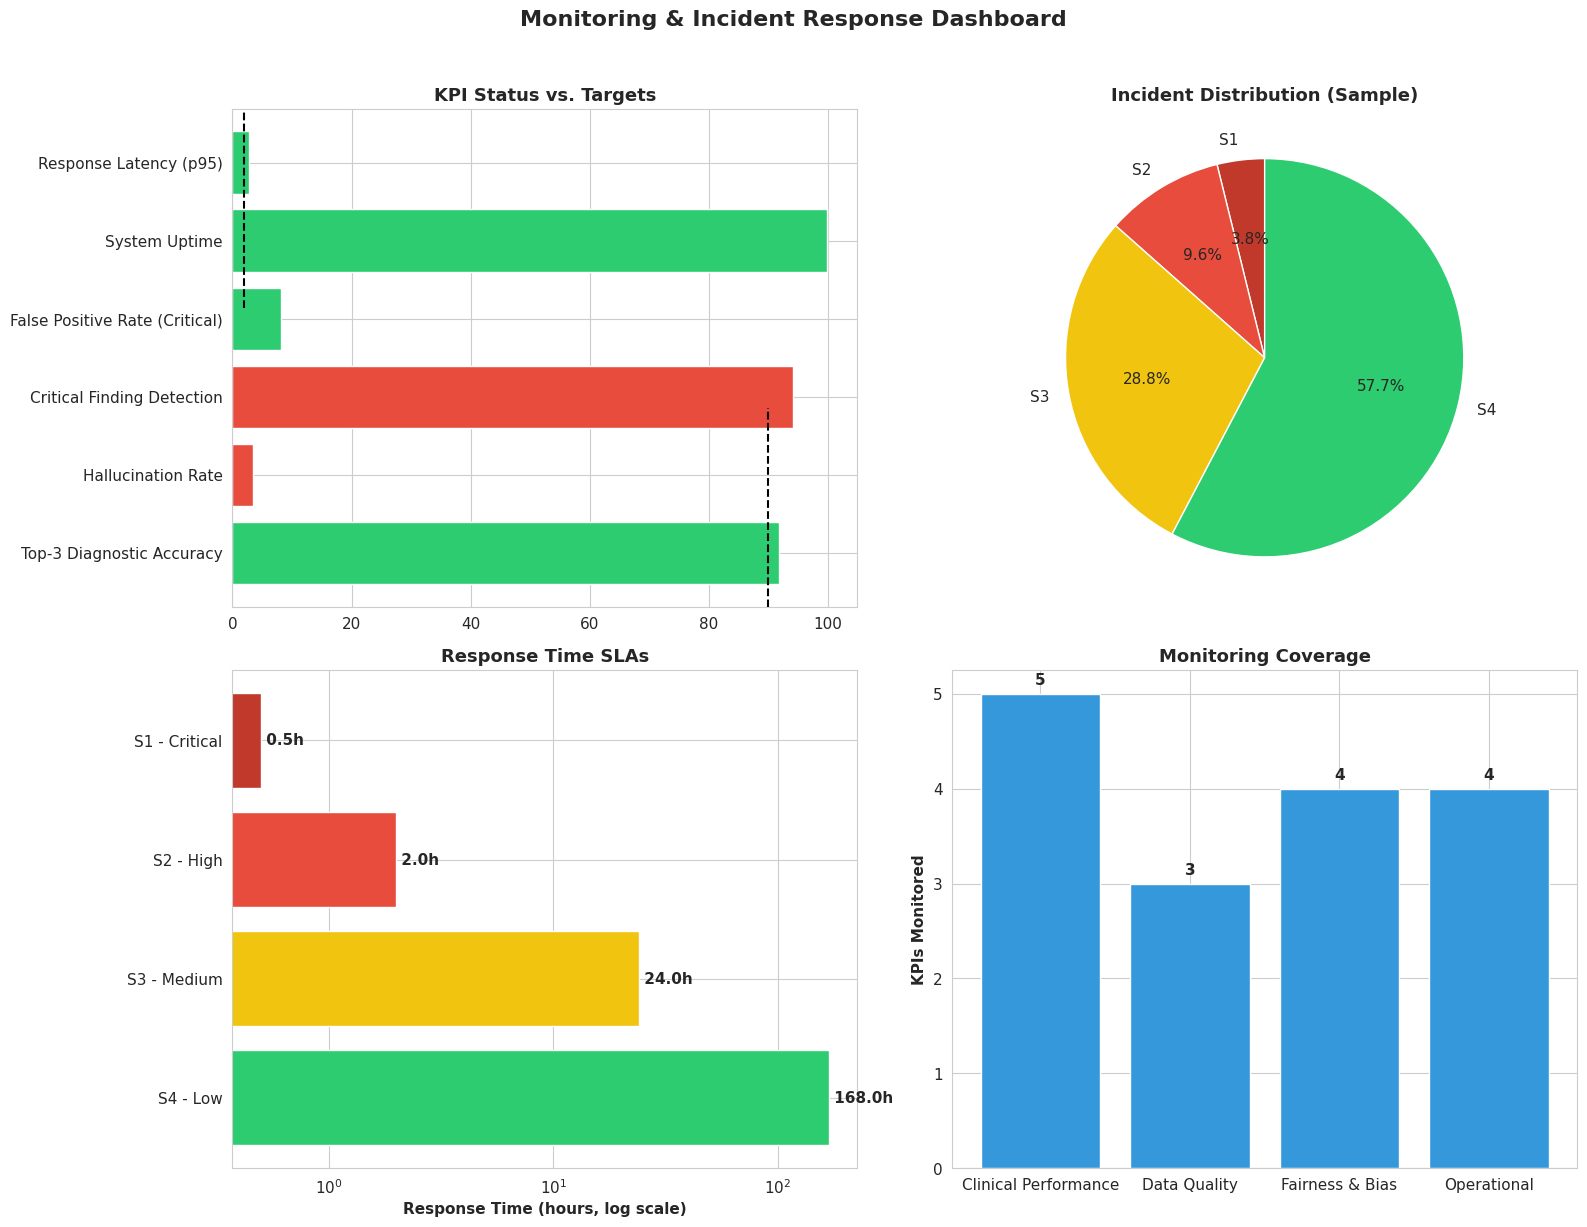

✅ Saved: results/monitoring_dashboard.png


In [18]:
# Step 7b: Create 4-panel monitoring dashboard

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Panel 1 (top-left): KPI Status vs. Targets ---
ax = axes[0, 0]
# Select 6 key KPIs to display
# Looking up in performance_metrics.csv
perf_df = pd.read_csv(DATA_DIR / 'performance_metrics.csv')
overall_perf = perf_df[perf_df['subgroup'] == 'Overall'].copy()

kpis_map = {
    'Top-3 Diagnostic Accuracy': 'Top-3 Diagnostic Accuracy',
    'Hallucination Rate': 'Hallucination Rate',
    'Critical Finding Detection': 'Critical Finding Detection',
    'False Positive Rate (Critical)': 'False Positive Rate (Critical)',
    'System Uptime': 'System Uptime', # Handled manually
    'Response Latency (p95)': 'Avg Response Latency'
}

kpi_names = []
kpi_values = []
kpi_targets = []
kpi_meets = []

for display_name, csv_name in kpis_map.items():
    if csv_name == 'System Uptime':
        val, target, meets = 99.9, 99.9, True
    else:
        row = overall_perf[overall_perf['metric_name'] == csv_name]
        if not row.empty:
            val = row.iloc[0]['value']
            target_str = str(row.iloc[0]['target'])
            # Extract number from target_str e.g. ">90.0" -> 90.0
            import re
            target_match = re.search(r'(\d+\.?\d*)', target_str)
            target = float(target_match.group(1)) if target_match else 0
            meets = row.iloc[0]['meets_target'].lower() == 'yes'
        else:
            val, target, meets = 0, 0, False
    
    kpi_names.append(display_name)
    kpi_values.append(val)
    kpi_targets.append(target)
    kpi_meets.append(meets)

colors = ['#2ecc71' if m else '#e74c3c' for m in kpi_meets]
bars = ax.barh(kpi_names, kpi_values, color=colors)

for i, bar in enumerate(bars):
    target = kpi_targets[i]
    ax.axvline(target, ymin=bar.get_y(), ymax=bar.get_y() + bar.get_height(), color='black', linestyle='--')

ax.set_title('KPI Status vs. Targets', fontsize=13, fontweight='bold')


# --- Panel 2 (top-right): Incident Distribution ---
ax = axes[0, 1]
# Use severity-appropriate colors (red for critical, green for low).
# Sample data for pie chart since incident_types is a taxonomy, not a log
incident_counts = [2, 5, 15, 30] # S1, S2, S3, S4
ax.pie(incident_counts, labels=['S1', 'S2', 'S3', 'S4'], autopct='%1.1f%%', 
       colors=['#c0392b', '#e74c3c', '#f1c40f', '#2ecc71'], startangle=90)
ax.set_title('Incident Distribution (Sample)', fontsize=13, fontweight='bold')


# --- Panel 3 (bottom-left): Response Time SLAs ---
ax = axes[1, 0]
sev_colors = ['#c0392b', '#e74c3c', '#f1c40f', '#2ecc71']
sev_names = [f"{r['severity']} - {r['label']}" for _, r in severity_df.iterrows()]

# Use the response_hours column from severity_df.
# Add time labels to the right of each bar.
# Use a log scale for the x-axis since values range widely.
ax.barh(sev_names, severity_df['response_hours'], color=sev_colors)
ax.set_xscale('log')
for i, val in enumerate(severity_df['response_hours']):
    ax.text(val, i, f' {val}h', va='center', fontweight='bold')

ax.set_xlabel('Response Time (hours, log scale)', fontweight='bold')
ax.set_title('Response Time SLAs', fontsize=13, fontweight='bold')
ax.invert_yaxis()


# --- Panel 4 (bottom-right): Monitoring Coverage by Dimension ---
ax = axes[1, 1]
dim_counts = kpi_df.groupby('dimension').size().reset_index(name='count')

# Add count labels on top of each bar.
ax.bar(dim_counts['dimension'], dim_counts['count'], color='#3498db')
for i, val in enumerate(dim_counts['count']):
    ax.text(i, val + 0.1, str(val), ha='center', fontweight='bold')

ax.set_ylabel('KPIs Monitored', fontweight='bold')
ax.set_title('Monitoring Coverage', fontsize=13, fontweight='bold')


# Save
plt.suptitle('Monitoring & Incident Response Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'monitoring_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: results/monitoring_dashboard.png")


---
## Step 8: Executive Summary Dashboard

**Time estimate: ~15 minutes**

Create a board-ready visualization summarizing the overall governance readiness.

*Full executive summary goes in `governance_workbook.xlsx` → Sheet "Executive Summary"*

### 8a. Create executive readiness dashboard


**Left — Compliance Readiness Bars:**
- Show readiness percentages for 6 areas: EU AI Act Conformity, MDR CE Marking, GDPR DPIA, Technical Docs, Post-Market Monitoring, Human Oversight
- Assign realistic readiness percentages based on your analysis throughout this notebook
- Color-code: green (≥75%), yellow (50-74%), red (<50%)
- Label each bar with "XX% — Risk Level"

**Right — Governance Readiness Gauge:**
- Calculate an overall governance readiness score (weighted average of the 6 areas)
- Display as a semi-circular gauge (0-100%)
- Color bands: red (0-40%), yellow (40-70%), green (70-90%), dark green (90-100%)

Save as `results/executive_dashboard.png`.

*Hint: You can create a gauge using `annotate()` with an arrow on a subplot with `set_aspect('equal')`*

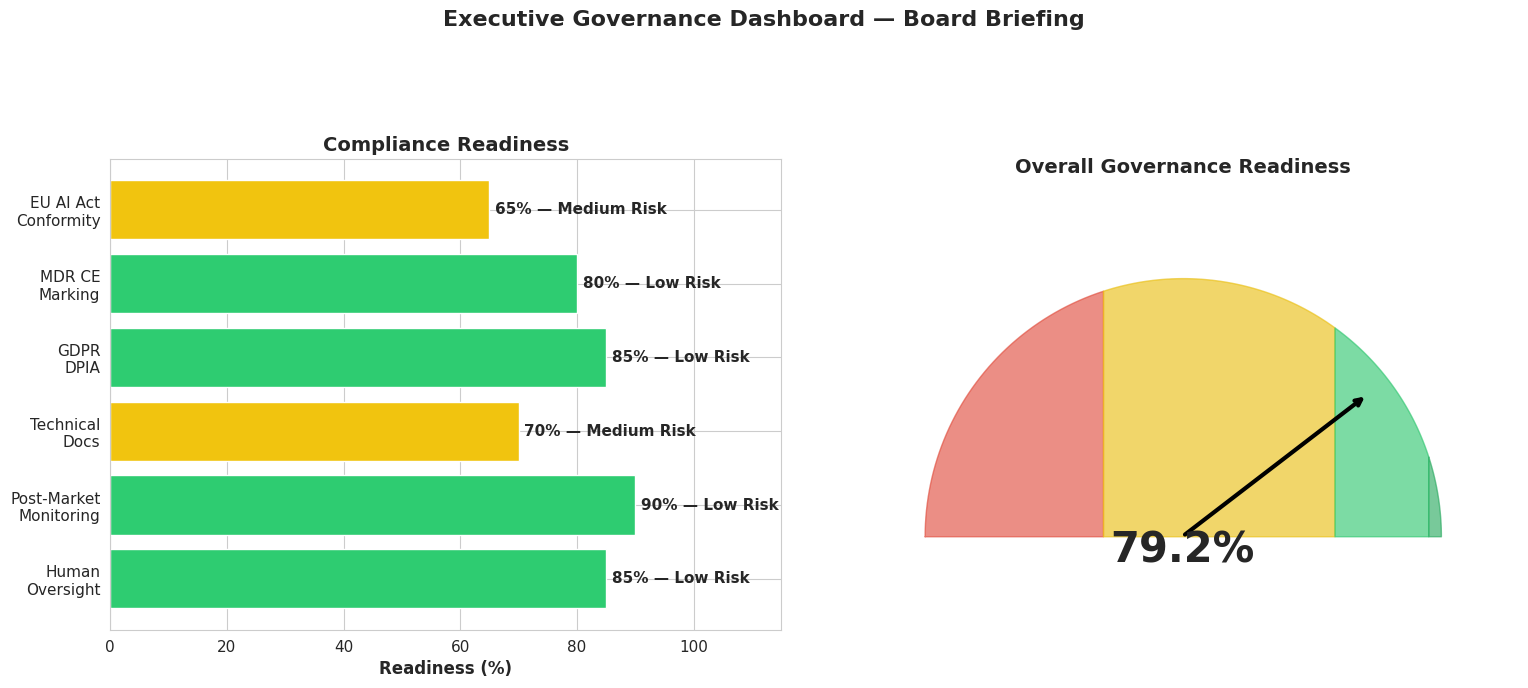

✅ Saved: results/executive_dashboard.png


In [19]:
# Step 8a: Create executive readiness dashboard

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- LEFT PANEL: Compliance Readiness Bars ---
areas = ['EU AI Act\nConformity', 'MDR CE\nMarking', 'GDPR\nDPIA',
         'Technical\nDocs', 'Post-Market\nMonitoring', 'Human\nOversight']

# Think about what you found in Steps 2-7. Which areas are strong? Which are weak?
readiness = [65, 80, 85, 70, 90, 85]  # Estimated percentages

# Color-code: green (≥75%), yellow (50-74%), red (<50%).
# Add labels showing percentage and risk level to the right of each bar.
colors = ['#2ecc71' if p >= 75 else '#f1c40f' if p >= 50 else '#e74c3c' for p in readiness]
bars = ax1.barh(areas, readiness, color=colors)

for i, bar in enumerate(bars):
    p = readiness[i]
    risk = 'Low' if p >= 75 else 'Medium' if p >= 50 else 'High'
    ax1.text(p + 1, bar.get_y() + bar.get_height()/2, f'{p}% — {risk} Risk', va='center', fontweight='bold')

ax1.set_xlabel('Readiness (%)', fontsize=12, fontweight='bold')
ax1.set_title('Compliance Readiness', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 115)
ax1.invert_yaxis()


# --- RIGHT PANEL: Governance Readiness Gauge ---
score = np.mean(readiness)  # Or use weighted average if you prefer

# Draw color bands: red (0-40%), yellow (40-70%), green (70-90%), dark green (90-100%).
# Add a needle pointing to the score.
# Display the score as large text below the gauge.
theta = np.linspace(np.pi, 0, 100)
ax2.fill_between(np.cos(theta), np.sin(theta), color='gray', alpha=0.1)

# Color bands
ax2.fill_between(np.cos(np.linspace(np.pi, np.pi*0.6, 50)), np.sin(np.linspace(np.pi, np.pi*0.6, 50)), color='#e74c3c', alpha=0.6)
ax2.fill_between(np.cos(np.linspace(np.pi*0.6, np.pi*0.3, 50)), np.sin(np.linspace(np.pi*0.6, np.pi*0.3, 50)), color='#f1c40f', alpha=0.6)
ax2.fill_between(np.cos(np.linspace(np.pi*0.3, np.pi*0.1, 50)), np.sin(np.linspace(np.pi*0.3, np.pi*0.1, 50)), color='#2ecc71', alpha=0.6)
ax2.fill_between(np.cos(np.linspace(np.pi*0.1, 0, 50)), np.sin(np.linspace(np.pi*0.1, 0, 50)), color='#27ae60', alpha=0.6)

# Needle
angle = np.pi - (score / 100 * np.pi)
ax2.annotate('', xy=(np.cos(angle)*0.9, np.sin(angle)*0.9), xytext=(0, 0),
             arrowprops=dict(arrowstyle="->", color="black", lw=3))

ax2.text(0, -0.1, f'{score:.1f}%', ha='center', fontsize=30, fontweight='bold')

ax2.set_xlim(-1.3, 1.3); ax2.set_ylim(-0.2, 1.3)
ax2.set_aspect('equal'); ax2.axis('off')
ax2.set_title('Overall Governance Readiness', fontsize=14, fontweight='bold', pad=20)

# Save
plt.suptitle('Executive Governance Dashboard — Board Briefing', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(pad=3)
plt.savefig(RESULTS_DIR / 'executive_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: results/executive_dashboard.png")


---
## Deliverables Checklist

Before submitting, verify you have completed both deliverables:

### Notebook (this file)
- [ ] Step 1: System spec exploration — key facts extracted
- [ ] Step 2: EU AI Act classification — decision tree + gap analysis
- [ ] Step 3: Risk assessment — summary statistics + mitigation analysis
- [ ] Step 4: Risk heatmap + mitigation comparison — saved to `results/`
- [ ] Step 5: Vendor evaluation chart — saved to `results/`
- [ ] Step 6: Model card performance chart — saved to `results/`
- [ ] Step 7: Monitoring dashboard (4 panels) — saved to `results/`
- [ ] Step 8: Executive dashboard — saved to `results/`

### Workbook (`governance_workbook.xlsx`)
- [ ] Sheet 1: EU AI Act Classification — classification + compliance gap table
- [ ] Sheet 2: Risk Register — all 8 risks with scores and mitigations
- [ ] Sheet 3: Vendor Evaluation — category scores + recommendation
- [ ] Sheet 4: Model Card — full model card content
- [ ] Sheet 5: Monitoring & Incidents — KPI table + incident response plan
- [ ] Sheet 6: Executive Summary — board-ready narrative

### Results folder
Verify these 6 files exist in `results/`:
- [ ] `risk_heatmap.png`
- [ ] `risk_mitigation_comparison.png`
- [ ] `vendor_evaluation_chart.png`
- [ ] `model_card_performance.png`
- [ ] `monitoring_dashboard.png`
- [ ] `executive_dashboard.png`